# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.
Berikut adalah draf perkenalan dataset yang komprehensif dan profesional, disusun agar pembaca laporan Anda langsung memahami konteks, isi, dan relevansi data yang Anda gunakan.


  Deskripsi Dataset: Ulasan Pengguna Aplikasi "Stella Sora"
 proyek ini menggunakan dataset yang berisi kumpulan ulasan pengguna (user reviews) terhadap aplikasi permainan seluler (mobile game) bernama "Stella Sora" (nama disamarkan/digeneralisasi sesuai konteks proyek). Dataset ini merupakan data sekunder yang mencerminkan opini publik secara real-time mengenai performa, fitur, dan kepuasan pengguna terhadap aplikasi tersebut.

1. Sumber dan Asal Data
Sumber: Dataset ini dikumpulkan dari platform distribusi aplikasi publik, yaitu Google Play Store.

Jenis Data: Data tidak terstruktur berupa teks (textual data) yang disertai dengan metadata pendukung seperti rating numerik dan tanggal ulasan.

Volume Data: Dataset ini terdiri dari 15.000 baris data (entries), yang merepresentasikan 15.000 ulasan unik dari pengguna.

2. Karakteristik Fitur (Variabel Data)
Dataset ini memiliki 9 kolom utama yang memberikan informasi mendalam mengenai setiap ulasan. Berikut adalah penjelasan variabel-variabel tersebut:

a. username: Identitas pengguna yang memberikan ulasan (mayoritas disamarkan sebagai "Pengguna Google" untuk privasi).

b. rating: Skor kepuasan yang diberikan pengguna dengan skala 1 hingga 5. Skor ini merepresentasikan sentimen kasar (1 = Sangat Buruk, 5 = Sangat Baik) dan akan digunakan sebagai validasi label sentimen.

c. text: Isi ulasan asli dari pengguna. Kolom ini berisi opini mentah yang mencakup berbagai topik seperti gameplay, sistem gacha, grafik, hingga keluhan teknis (bug/lag).

d. date: Waktu (tanggal dan jam) ketika ulasan tersebut dipublikasikan. Informasi ini berguna untuk analisis tren sentimen berdasarkan waktu (misalnya: lonjakan sentimen negatif setelah update tertentu).

f.thumbsUp: Jumlah pengguna lain yang menyukai ulasan tersebut, mengindikasikan seberapa relevan atau bermanfaat ulasan itu bagi komunitas.

g. translated_text & clean_text: Kolom tambahan yang berisi teks yang telah diterjemahkan atau dibersihkan dari simbol-simbol yang tidak relevan, siap untuk diproses lebih lanjut dalam tahap preprocessing.



# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [3]:
#Type your code here
!pip install nltk sastrawi scikit-learn gensim pandas numpy wordcloud

import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from wordcloud import WordCloud

# Download resource NLTK (jika belum ada)
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

print("Library berhasil diimport.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 105.8 MB/s eta 0:00:00
Library berhasil diimport.


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [4]:
#Type your code here
df_reviews = pd.read_csv('dataset_stella_sora_original.csv', engine='python', on_bad_lines='warn')
df_reviews.head()

,username,rating,text,date,thumbsUp,replyContent,replyDate,translated_text,clean_text
0,Pengguna Google,5,bagus ROUGEKILL,2025-10-27 16:47:42,0,NaN,NaN,bagus ROUGEKILL,bagus ROUGEKILL
1,Pengguna Google,5,game keren udah ga kikir,2025-10-27 16:24:45,0,NaN,NaN,game keren udah ga kikir,game keren udah ga kikir
2,Pengguna Google,5,bagus,2025-10-27 16:11:57,0,NaN,NaN,bagus,bagus
3,Pengguna Google,1,akhirnya berbenah 🤏,2025-10-27 16:08:43,0,NaN,NaN,akhirnya berbenah 🤏,akhirnya berbenah 🤏
4,Pengguna Google,4,"gacha mahal, kontrol agak ngelag UI, gameplay,...",2025-10-27 15:55:27,0,NaN,NaN,"gacha mahal, kontrol agak ngelag UI, gameplay,...","gacha mahal, kontrol agak ngelag UI, gameplay,..."


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

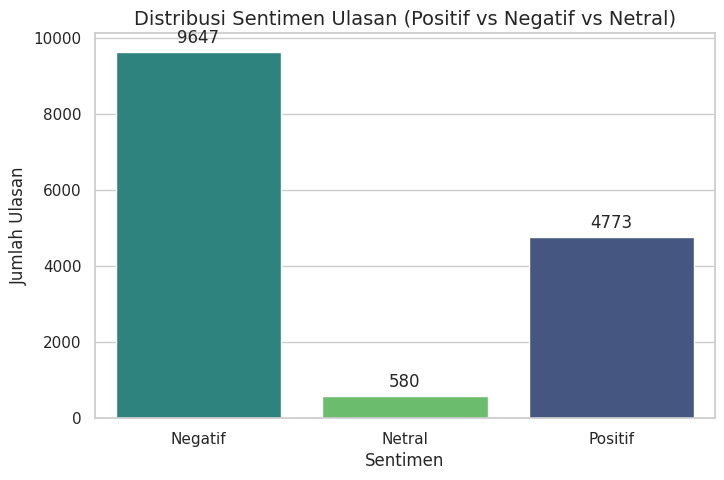

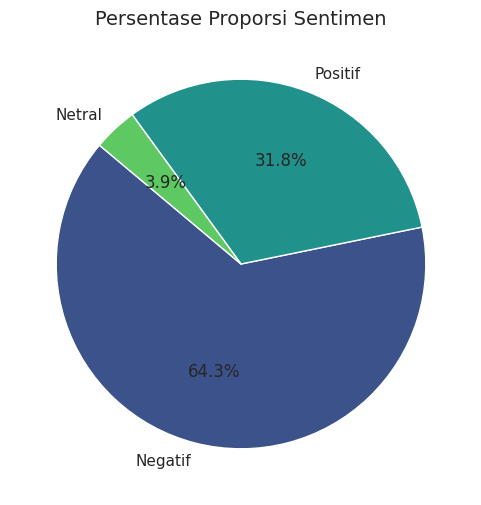

Generating Word Cloud for Positive Reviews...


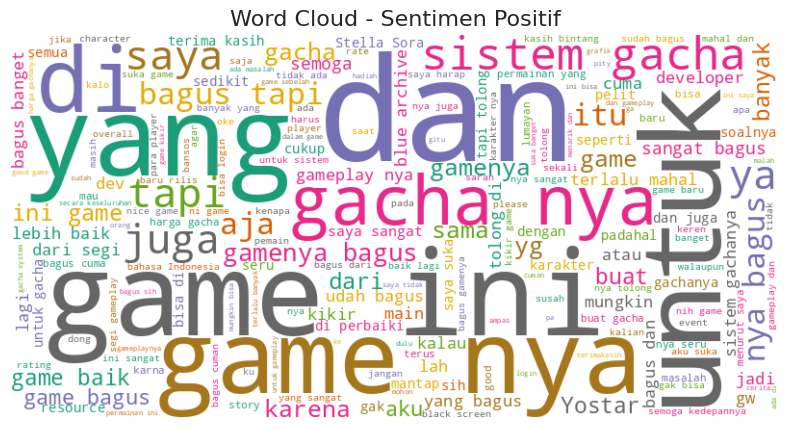

Generating Word Cloud for Negative Reviews...


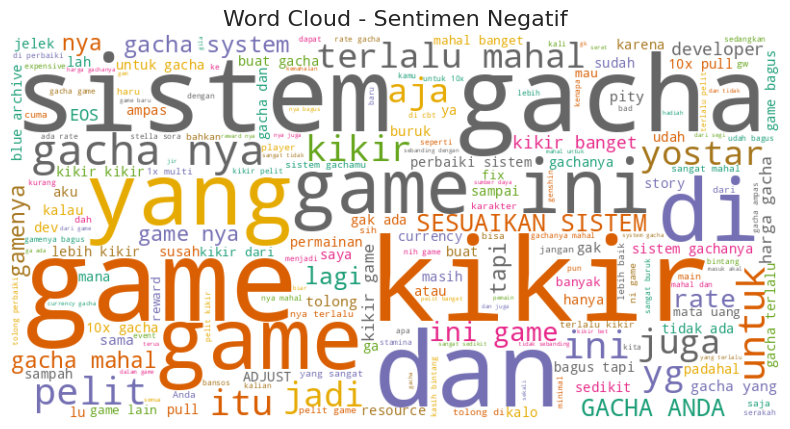

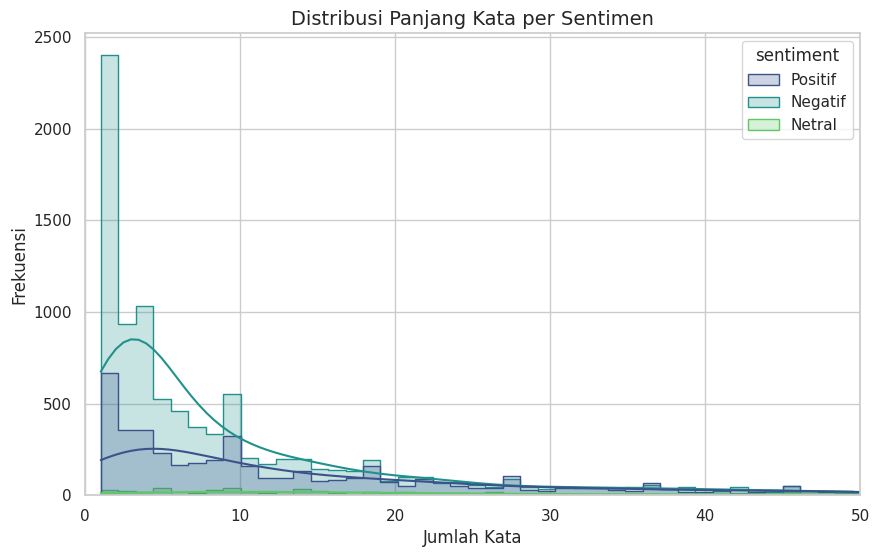

In [5]:
#Type your code here
# Set gaya visualisasi
sns.set(style="whitegrid")

# Tambahkan kolom sentimen berdasarkan rating
def classify_sentiment(rating):
    if rating >= 4:
        return 'Positif'
    elif rating == 3:
        return 'Netral'
    else:
        return 'Negatif'

df_reviews['sentiment'] = df_reviews['rating'].apply(classify_sentiment)

# 1. Visualisasi Distribusi Sentimen (Bar Chart)
plt.figure(figsize=(8, 5))
# Addressing FutureWarning: Passing `palette` without assigning `hue` is deprecated.
# Assign 'sentiment' to `hue` and set `legend=False` for the same effect.
ax = sns.countplot(x='sentiment', data=df_reviews, hue='sentiment', palette='viridis', order=['Negatif', 'Netral', 'Positif'], legend=False)

# Menambahkan label angka di atas batang
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.title('Distribusi Sentimen Ulasan (Positif vs Negatif vs Netral)', fontsize=14)
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Ulasan')
plt.show()

# 2. Visualisasi Persentase (Pie Chart)
plt.figure(figsize=(6, 6))
sentiment_counts = df_reviews['sentiment'].value_counts()
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis', 3))
plt.title('Persentase Proporsi Sentimen', fontsize=14)
plt.show()

# Fungsi untuk membuat Word Cloud
def generate_wordcloud(text_data, title):
    all_text = ' '.join(text_data.astype(str))
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Dark2').generate(all_text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16)
    plt.show()

# Word Cloud untuk Sentimen Positif
print("Generating Word Cloud for Positive Reviews...")
df_positif = df_reviews[df_reviews['sentiment'] == 'Positif']
generate_wordcloud(df_positif['clean_text'], 'Word Cloud - Sentimen Positif')

# Word Cloud untuk Sentimen Negatif
print("Generating Word Cloud for Negative Reviews...")
df_negatif = df_reviews[df_reviews['sentiment'] == 'Negatif']
generate_wordcloud(df_negatif['clean_text'], 'Word Cloud - Sentimen Negatif')

# Hitung jumlah kata per ulasan
df_reviews['word_count'] = df_reviews['clean_text'].apply(lambda x: len(str(x).split()))

# Plot Histogram Distribusi Jumlah Kata
plt.figure(figsize=(10, 6))
sns.histplot(data=df_reviews, x='word_count', hue='sentiment', kde=True, element="step", palette='viridis')
plt.title('Distribusi Panjang Kata per Sentimen', fontsize=14)
plt.xlabel('Jumlah Kata')
plt.ylabel('Frekuensi')
plt.xlim(0, 50) # Membatasi tampilan x-axis agar tidak terlalu panjang (bisa disesuaikan)
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [6]:
#cleaning
print(f"Jumlah data sebelum filtering: {len(df_reviews)}")
df_reviews = df_reviews[df_reviews['text'].notna()]
print(f"Setelah hapus text None: {len(df_reviews)}")
df_reviews = df_reviews[df_reviews['clean_text'].str.len() > 2]
print(f"Setelah hapus text < 5 karakter: {len(df_reviews)}")
df_reviews = df_reviews[df_reviews['clean_text'].str.strip() != '']
print(f"Setelah hapus text kosong: {len(df_reviews)}")

print(f"\nTotal data yang dihapus: {15000 - len(df_reviews)}")
print(f"Total data final: {len(df_reviews)}")

#preprosesing
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

stemmer_factory = StemmerFactory()
stemmer = stemmer_factory.create_stemmer()

def clean_text(text):

    if pd.isna(text):
        return ""

    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = stopword_remover.remove(text)
    text = stemmer.stem(text)

    return text

print("proses 'text'...")
df_reviews['clean_text'] = df_reviews['text'].apply(clean_text)
print("Preprocessing selesai!")

for i in range(5):
    print(f"\n[{i+1}]")
    print(f"Original: {df_reviews.iloc[i]['text'][:100]}...")
    print(f"Cleaned:  {df_reviews.iloc[i]['clean_text'][:100]}...")

#labeling
def label_sentiment(rating):
    if rating <= 2:
        return 'Negatif'
    elif rating == 3:
        return 'Netral'
    else:
        return 'Positif'

df_reviews['sentiment'] = df_reviews['rating'].apply(label_sentiment)

sentiment_counts = df_reviews['sentiment'].value_counts()
print(sentiment_counts)

sentiment_pct = df_reviews['sentiment'].value_counts(normalize=True) * 100
for label, pct in sentiment_pct.items():
    print(f"{label}: {pct:.2f}%")
#encoding
X = df_reviews['clean_text']
y = df_reviews['sentiment']

print(f"\nData yang akan digunakan untuk modeling:")
print(f"  X (Features) : kolom 'clean_text' ")
print(f"  y (Target)   : kolom 'sentiment' ")
print(f"  Total sampel : {len(X)}")

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"\n{'='*70}")
print("Mapping")
print(f"{'='*70}")
for i, label in enumerate(label_encoder.classes_):
    count = np.sum(y_encoded == i)
    print(f"  {label:8s} → {i}  (jumlah: {count:5d} sampel | {count/len(y_encoded)*100:5.2f}%)")

X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(
    X, y_encoded,
    test_size=0.3,
    random_state=42,
    stratify=y_encoded
)

print(f"\nPembagian Data:")
print(f"  Training: {len(X_train_3)} samples ({len(X_train_3)/len(X)*100:.1f}%)")
print(f"  Testing:  {len(X_test_3)} samples ({len(X_test_3)/len(X)*100:.1f}%)")


print("\nMelakukan TF-IDF Vectorization...")
tfidf_vectorizer_3 = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.8
) # Added the missing closing parenthesis

Jumlah data sebelum filtering: 15000
Setelah hapus text None: 15000
Setelah hapus text < 5 karakter: 14929
Setelah hapus text kosong: 14929

Total data yang dihapus: 71
Total data final: 14929
proses 'text'...
Preprocessing selesai!

[1]
Original: bagus ROUGEKILL...
Cleaned:  bagus rougekill...

[2]
Original: game keren udah ga kikir...
Cleaned:  game keren udah ga kikir...

[3]
Original: bagus...
Cleaned:  bagus...

[4]
Original: akhirnya berbenah 🤏...
Cleaned:  akhir benah...

[5]
Original: gacha mahal, kontrol agak ngelag UI, gameplay, animasi, skill, desain, pergerakan, tampilan udah bag...
Cleaned:  gacha mahal kontrol ngelag ui gameplay animasi skill desain gera tampil udah bagus...
sentiment
Negatif    9619
Positif    4730
Netral      580
Name: count, dtype: int64
Negatif: 64.43%
Positif: 31.68%
Netral: 3.89%

Data yang akan digunakan untuk modeling:
  X (Features) : kolom 'clean_text' 
  y (Target)   : kolom 'sentiment' 
  Total sampel : 14929

Mapping
  Negatif  → 0  (jumlah: 

In [7]:
import pandas as pd
from google.colab import files

# --- Konfigurasi ---
# Ganti 'df_reviews' dengan nama variabel dataframe terakhir Anda yang sudah diproses
target_dataframe = df_reviews
nama_file_output = 'dataset_bersih.csv'

# 1. Simpan dataframe ke file CSV
print(f"Menyimpan data ke {nama_file_output}...")
target_dataframe.to_csv(nama_file_output, index=False)

# 2. Download file secara otomatis
print("Memulai download...")
files.download(nama_file_output)

Menyimpan data ke dataset_bersih.csv...
Memulai download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install pipreqs
!jupyter nbconvert --to script model.ipynb
!pipreqs . --force

print("\n--- Selesai! ---")
print("File requirements.txt telah dibuat atau diperbarui.")